In [1]:
# import packages
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# allow matplotlib inline plotting
%matplotlib inline

In [5]:
# load the clean churn data and create a backup dataframe
df = pd.read_csv('churn_clean_data.csv')
df_backup = df.copy()

In [3]:
# verify the csv loaded successfully
df.head()

,Unnamed: 0.1,Unnamed: 0,CaseOrder,Customer_id,Interaction,City,State,County,Zip,Lat,...,MonthlyCharge,Bandwidth_GB_Year,item1,item2,item3,item4,item5,item6,item7,item8
0,0,1,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,...,171.449762,904.536110,5,5,5,3,4,4,3,4
1,1,2,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,West Branch,MI,Ogemaw,48661,44.32893,...,242.948015,800.982766,3,4,3,3,4,3,4,4
2,2,3,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,Yamhill,OR,Yamhill,97148,45.35589,...,159.440398,2054.706961,4,4,2,4,4,3,3,3
3,3,4,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,Del Mar,CA,San Diego,92014,32.96687,...,120.249493,2164.579412,4,4,4,2,5,4,3,3
4,4,5,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,Needville,TX,Fort Bend,77461,29.38012,...,150.761216,271.493436,4,4,4,3,4,4,4,5


In [7]:
# select the applicable continuous variables and store them in a new dataframe
var_df = df[['Income', 'Outage_sec_perweek', 'Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year']]

In [9]:
# normalize the data using standardization (mean normalization)
var_normalized = (var_df - var_df.mean()) / var_df.std()

In [11]:
# create the pca variable and fit it to the normalized data
pca = PCA(n_components = var_df.shape[1])
pca.fit(var_normalized)

PCA(n_components=5)

In [13]:
# convert the normalized data frame to a  new dataframe
pca_df = pd.DataFrame(pca.transform(var_normalized), columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

In [15]:
# view the pca loadings matrix
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], index=var_df.columns)
loadings

,PC1,PC2,PC3,PC4,PC5
Income,0.005975,-0.001356,0.997951,-0.063676,0.000843
Outage_sec_perweek,0.022378,0.705639,0.045918,0.706728,0.000158
Tenure,0.705360,-0.057918,-0.001425,0.035745,-0.705573
MonthlyCharge,0.045469,0.706129,-0.044166,-0.703600,-0.048063
Bandwidth_GB_Year,0.707010,-0.009953,-0.005625,-0.012242,0.707005


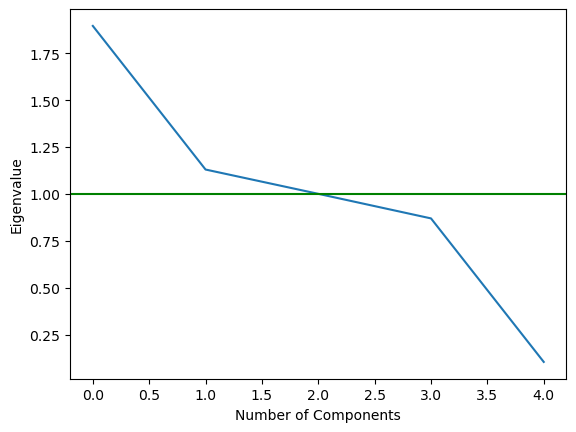

In [17]:
# calculate covariance matrix, eigenvalues, and plot them
cov_matrix = np.dot(var_normalized.T, var_normalized) / var_df.shape[0]
eigenvalues = [np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)) for eigenvector in pca.components_]
plt.plot(eigenvalues)
plt.xlabel('Number of Components')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='green')
plt.show()